# IMPORT LIBRARY

In [70]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine

# CONNECTING TO DATABASE

In [71]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


# LISTING EFFICIENCY & PROPERTY MARKET VALUATION

##

##
RETRIVE DATA

In [72]:
dataset = '''
            SELECT
                l.listing_id
                ,t.transaction_id
                ,p.property_id
                ,l.listing_date
                ,l.close_date
                ,t.deal_date
                ,t.deal_price
                ,p.city
                ,l.listed_price
                ,l.listing_status
                ,l.listing_channel
                ,t.deal_status
                ,p.property_type
                ,p.size_sqm
                ,p.year_built
                ,p.location_score
                ,p.has_parking
                ,p.near_transit
                ,p.near_school
                ,p.list_price
                ,p.amenities_count
            FROM listings l
            FULL OUTER JOIN transactions t ON l.listing_id = t.listing_id
            FULL OUTER JOIN properties p ON l.property_id = p.property_id
            WHERE DATE_PART('year',listing_date)<=2024 OR listing_date IS NULL
            '''
df_dataset = pd.read_sql(dataset,conn)
df_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 9183 entries, 0 to 9182
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   listing_id       8500 non-null   str    
 1   transaction_id   3922 non-null   str    
 2   property_id      9183 non-null   str    
 3   listing_date     8500 non-null   object 
 4   close_date       5618 non-null   object 
 5   deal_date        3922 non-null   object 
 6   deal_price       3922 non-null   float64
 7   city             9183 non-null   str    
 8   listed_price     8500 non-null   float64
 9   listing_status   8500 non-null   str    
 10  listing_channel  8500 non-null   str    
 11  deal_status      3922 non-null   str    
 12  property_type    9183 non-null   str    
 13  size_sqm         9183 non-null   float64
 14  year_built       9183 non-null   int64  
 15  location_score   9183 non-null   float64
 16  has_parking      9183 non-null   str    
 17  near_transit     9183 non

In [73]:
df_dataset['deal_date'] = pd.to_datetime(df_dataset['deal_date'])
df_dataset['listing_date'] = pd.to_datetime(df_dataset['listing_date'])
df_dataset['close_date'] = pd.to_datetime(df_dataset['close_date'])

## 
LISTING AND MARKET VELOCITY METRICS

> LISTING ANALYSIS

>> 1) Listing Overview

In [74]:
df_listing = (\
    df_dataset[(~df_dataset['listing_id'].isna())]
    )

df_listing['days_on_market'] = np.where(\
    df_listing['close_date'].isna(),
    (pd.Timestamp('2024-12-31') - df_listing['listing_date']).dt.days,
    (df_listing['close_date'] - df_listing['listing_date']).dt.days
)

In [75]:
df_completed = (df_listing[
    (df_listing['deal_status']=='Completed') & ((df_listing['deal_date'].dt.year)<=2024)]
)

In [76]:
total_listing = (df_listing['listing_id'].count())
avg_completed_DOM = df_completed['days_on_market'].mean()
total_listing_value = (df_listing['listed_price'].sum())
listing_convertion_rate = round(\
                (df_completed['listing_id'].count())
                /total_listing*100,2)

print(f'Total Listing : {total_listing}')
print(f'Average Completed Transaction DOM : {avg_completed_DOM:.0f} Days')
print(f'Listing Convertion Rate : {listing_convertion_rate:.2f}%')


Total Listing : 8500
Average Completed Transaction DOM : 45 Days
Listing Convertion Rate : 43.96%


>> 2. Available Listing Distribution

In [77]:

available_listing = []
years = (df_listing['listing_date'].dt.year).unique()

for year in years:
    start_date = pd.Timestamp(f'{year}-01-01')
    end_date = pd.Timestamp(f'{year}-12-31')
    carry_over = df_listing[
        (df_listing['listing_date']< start_date ) &
        ((df_listing['close_date'] >= start_date)|
         (df_listing['close_date'].isna()))
    ]['listing_id'].nunique()

    new_listing = df_listing[
        (df_listing['listing_date']>=start_date) &
        ((df_listing['listing_date']<=end_date))]['listing_id'].nunique()
    
    carry_over_trans = df_completed[
        (df_completed['deal_date'] >= start_date) &
        (df_completed['deal_date'] <= end_date) &
        (df_completed['listing_date'] < start_date)
    ]['listing_id'].nunique()


    new_listing_trans = df_completed[
        (df_completed['deal_date'] >= start_date) &
        (df_completed['deal_date'] <= end_date) &
        (df_completed['listing_date'] >= start_date)
    ]['listing_id'].nunique()
    
    available_listing.append(
        {'year': year,
         'carry_over_listing': carry_over,
         'new_listing': new_listing,
         'carry_over_trans' : carry_over_trans,
         'new_listing_trans': new_listing_trans}
    )

annual_avail_list_distribution = pd.DataFrame(available_listing)

annual_avail_list_distribution['total_avail_listing'] = (\
    annual_avail_list_distribution['carry_over_listing'] +
    annual_avail_list_distribution['new_listing'])

annual_avail_list_distribution['total_trans'] = (\
    annual_avail_list_distribution['carry_over_trans'] +
    annual_avail_list_distribution['new_listing_trans'])

annual_avail_list_distribution['carry_over_absroption_rate'] = (\
    annual_avail_list_distribution['carry_over_trans']/
    annual_avail_list_distribution['carry_over_listing']*100).round(2)

annual_avail_list_distribution['new_listing_absroption_rate'] = (\
    annual_avail_list_distribution['new_listing_trans']/
    annual_avail_list_distribution['new_listing']*100).round(2)
   
annual_avail_list_distribution = annual_avail_list_distribution.sort_values("year", ascending=True).reset_index(drop=True)
annual_avail_list_distribution

,year,carry_over_listing,new_listing,carry_over_trans,new_listing_trans,total_avail_listing,total_trans,carry_over_absroption_rate,new_listing_absroption_rate
0,2022,0,2879,0,1121,2879,1121,NaN,38.94
1,2023,1514,2771,151,1128,4285,1279,9.97,40.71
2,2024,2468,2850,133,1204,5318,1337,5.39,42.25


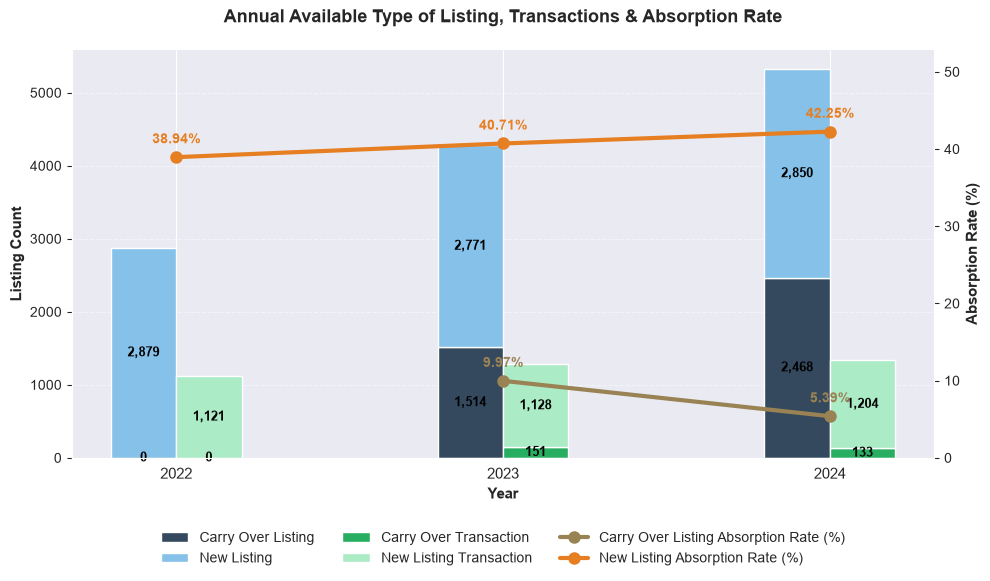

In [78]:
sns.set_style("darkgrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(annual_avail_list_distribution["year"]))
width = 0.2

rects1 = ax1.bar(
    x - width/2,
    annual_avail_list_distribution["carry_over_listing"],
    width,
    color="#34495E",
    label="Carry Over Listing",
)

rects2 = ax1.bar(
    x - width/2,
    annual_avail_list_distribution["new_listing"],
    width,
    bottom=annual_avail_list_distribution["carry_over_listing"],
    color="#85C1E9",
    label="New Listing",
)

rects3 = ax1.bar(
    x + width/2,
    annual_avail_list_distribution["carry_over_trans"],
    width,
    color="#27AE60",
    label="Carry Over Transaction",
)

rects4 = ax1.bar(
    x + width/2,
    annual_avail_list_distribution["new_listing_trans"],
    width,
    bottom=annual_avail_list_distribution["carry_over_trans"],
    color="#ABEBC6",
    label="New Listing Transaction",
)

ax1.set_ylabel("Listing Count", fontsize=11, fontweight="bold")
ax1.set_xlabel("Year", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(annual_avail_list_distribution["year"].astype(str), fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1+ rects3:
    height = rect.get_height()

    ax1.annotate(
        f"{int(height):,}",
        (
            rect.get_x() + rect.get_width()/2,
            rect.get_y() + height/2,
        ),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )

for rect in rects2+ rects4:
    height = rect.get_height()

    ax1.annotate(
        f"{int(height):,}",
        (
            rect.get_x() + rect.get_width()/2,
            rect.get_y() + height/2,
        ),
        ha="center",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="black",
    )
ax2 = ax1.twinx()

line1_color = "#998354"
line2_color = "#E67E22"

line1 = ax2.plot(
    x,
    annual_avail_list_distribution["carry_over_absroption_rate"],
    color=line1_color,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Carry Over Listing Absorption Rate (%)",
)

line2 = ax2.plot(
    x,
    annual_avail_list_distribution["new_listing_absroption_rate"],
    color=line2_color,
    marker="o",
    linewidth=3,
    markersize=8,
    label="New Listing Absorption Rate (%)",
)

ax2.set_ylabel("Absorption Rate (%)", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y")
ax2.grid(False)

max_rate = max(
    annual_avail_list_distribution["carry_over_absroption_rate"].max(),
    annual_avail_list_distribution["new_listing_absroption_rate"].max()
)
ax2.set_ylim(0, max_rate * 1.25)

for i, txt in enumerate(annual_avail_list_distribution["carry_over_absroption_rate"]):
    ax2.annotate(
        f"{txt:.2f}%",
        (x[i], txt),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color=line1_color,
        fontweight="bold",
        fontsize=10,
    )

for i, txt in enumerate(annual_avail_list_distribution["new_listing_absroption_rate"]):
    ax2.annotate(
        f"{txt:.2f}%",
        (x[i], txt),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        color=line2_color,
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Annual Available Type of Listing, Transactions & Absorption Rate",
    fontsize=13,
    fontweight="bold",
    pad=20,
    loc="center",
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol = 3,
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

sns.despine(top=True, right=False)
plt.tight_layout()
plt.show()


>> 3) Listing Aging Analysis

>>> a) Listing Aging Distribution

In [79]:
df_active = (\
    df_listing[
        (
            (df_listing['listing_status'] == 'Active') |
            (df_listing['close_date'].dt.year >= 2025)
        )
    ][['listing_id', 'listing_date', 'listed_price', 'days_on_market']]
    .reset_index(drop=True)
)

bins = [
    0,
    90,
    180,
    365,
    730,
    float('inf')
]

category = [
    'Fresh/New Listing',
    'Normal Exposure',
    'Aging Listing',
    'Long-Term Listing',
    'Stale Listing'
]

df_active['active_status'] = (\
    pd.cut(df_active['days_on_market'],
           bins,
           labels = category,
           include_lowest = True)
)

len(df_active)


3125

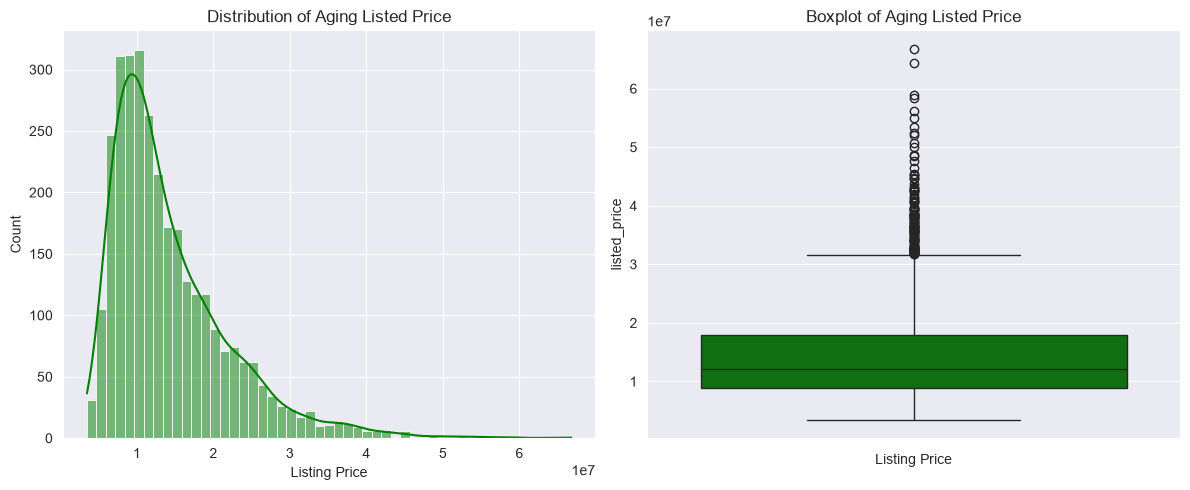

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(\
    data = df_active['listed_price'],
    kde=True,
    color='green',
    ax=axes[0]
)

axes[0].set_title('Distribution of Aging Listed Price')
axes[0].set_xlabel('Listing Price')

sns.boxplot(\
    data= df_active['listed_price'],
    color='green',
    ax=axes[1]
)

axes[1].set_title('Boxplot of Aging Listed Price')
axes[1].set_xlabel('Listing Price')

plt.tight_layout()
plt.show()

>>> b) Listing Aging Bukcet

In [81]:
listing_aging_bucket= (\
    df_active
    .groupby('active_status')
    .agg(listing_aging_count = ('listing_id','count'),
         listing_aging_value = ('listed_price','sum'))
    .reset_index()
)

listing_aging_bucket['listing_aging_share'] = (\
    round(
    listing_aging_bucket['listing_aging_count']/
    listing_aging_bucket['listing_aging_count'].sum()
    *100,2)
)


print(df_active['days_on_market'].describe())
print(f"\nTotal Listing Aging Value :\
{(listing_aging_bucket['listing_aging_value'].sum())/1e9:.2f}B")
print( f"Percent Total Listing Aging Value: \
{listing_aging_bucket['listing_aging_value'].sum() / total_listing_value * 100:.2f}%"
)
listing_aging_bucket

count    3125.000000
mean      463.482560
std       319.093756
min         7.000000
25%       177.000000
50%       428.000000
75%       723.000000
max      1116.000000
Name: days_on_market, dtype: float64

Total Listing Aging Value :44.84B
Percent Total Listing Aging Value: 37.19%


,active_status,listing_aging_count,listing_aging_value,listing_aging_share
0,Fresh/New Listing,461,6.298928e+09,14.75
1,Normal Exposure,340,4.821507e+09,10.88
2,Aging Listing,600,8.293944e+09,19.20
3,Long-Term Listing,954,1.403753e+10,30.53
4,Stale Listing,770,1.138613e+10,24.64


The listing aging thresholds were adjusted based on the actual distribution of listing duration in the dataset while following common real estate aging practices. Longer time on the market indicates slower inventory movement and may reduce sales efficiency due to delayed property conversion and unrealized commission opportunitie

| Days Active  | Category          | Interpretation                                                                                                                           |
| ------------ | ----------------- | ---------------------------------------------------------------------------------------------------------------------------------------- |
| 0–90 days    | Fresh/New Listing | Newly added listings that are still within the initial marketing period and have higher potential to attract buyer interest.             |
| 91–180 days  | Normal Exposure   | Properties that remain within a reasonable market exposure period and are still considered actively marketable.                          |
| 181–365 days | Aging Listing     | Listings that require evaluation of pricing strategy, property positioning, and marketing efforts due to longer time on the market.      |
| 366–730 days | Long-Term Listing | Older listings that indicate slower sales movement and may reduce listing turnover and sales efficiency.                                 |
| >730 days    | Stale Listing     | Highly aged listings with a higher risk of remaining unsold, requiring significant strategy adjustments to improve conversion potential. |


##
LISTING DIMENSION ANALYSIS

>>1) Property Listing Analysis

>>a) Listing per Property

In [82]:
df_listing['count_listing'] = (
    df_listing
    .groupby('property_id')['listing_id']
    .transform('count')
)

df_completed['count_listing'] = (
    df_completed
    .groupby('property_id')['listing_id']
    .transform('count')
)

df_completed['count_trans_prop'] = (
    df_completed
    .groupby('property_id')['transaction_id']
    .transform('count')
)


df_property = (
    df_dataset
    .drop_duplicates(subset='property_id')
    [['property_id', 'property_type', 'city',
      'size_sqm', 'year_built',
      'location_score', 'has_parking',
      'near_transit', 'near_school',
      'amenities_count']]
    .reset_index(drop=True)
)

listing_property = (
    df_listing
    .drop_duplicates(subset='property_id')
)

non_listing_property = (
    df_dataset[df_dataset['listing_id'].isna()]
    .drop_duplicates(subset='property_id')
)

multiple_listing_property = (
    df_listing[df_listing['count_listing'] > 1]
)

non_multiple_listing_property = (
    df_listing[df_listing['count_listing'] <= 1]
)

total_sold_property = df_completed['property_id'].nunique()

print(f'Total Number of Properties : {len(df_property)}')
print(f'Total Number of Sold Properties : {(total_sold_property)}')
print('---------')
print(f'Number of Properties with Listing Records : {len(listing_property)}')
print(f'Number of Properties without Listing Records : {len(non_listing_property)}')
print('---------')
print(f"Number of Properties with Multiple Listings : {len(multiple_listing_property.drop_duplicates(subset = 'property_id'))}")
print(f'Number of Properties with Single Listing : {len(non_multiple_listing_property)}')

listing_distribution = (
    df_listing
    .drop_duplicates('property_id')
    ['count_listing']
    .value_counts()
    .sort_index()
    .reset_index(name='property')
)

Total Number of Properties : 4500
Total Number of Sold Properties : 2516
---------
Number of Properties with Listing Records : 3817
Number of Properties without Listing Records : 683
---------
Number of Properties with Multiple Listings : 2534
Number of Properties with Single Listing : 1283


In [83]:
completed_multiple_listing = (\
    multiple_listing_property[
        (multiple_listing_property['deal_status']=='Completed') & 
        ((multiple_listing_property['deal_date'].dt.year)<= 2024)]
    )

completed_non_multiple_listing = (\
    non_multiple_listing_property[
        (non_multiple_listing_property['deal_status']=='Completed') & 
        ((non_multiple_listing_property['deal_date'].dt.year)<= 2024)]
)

convertion_rate_ml = (\
    round((len(completed_multiple_listing)/
           len(df_completed)*100),2)
)

convertion_rate_nml = (\
    round((len(completed_non_multiple_listing)/
           len(df_completed)*100),2)
)

property_convertion_rate_ml= (\
    round((len(completed_multiple_listing.drop_duplicates(subset = 'property_id'))/
           (total_sold_property)*100),2)
)

property_convertion_rate_nml =(\
    round((len(completed_non_multiple_listing.drop_duplicates(subset = 'property_id'))/
           (total_sold_property)*100),2)
)

multiple_selling_property = (
    df_completed[df_completed['count_trans_prop']>1]
    .drop_duplicates(subset='property_id')
)


print(f"Total Completed Transactions : {len(df_completed)}")
print("\nTransaction Contribution:")
print(f" Multiple Listing Properties :\
{len(completed_multiple_listing)}-({convertion_rate_ml}%)")
print(f" Single Listing Properties :\
{len(completed_non_multiple_listing)}-({convertion_rate_nml}%)")
print('---------')
print(f'Total Sold Properties : {(total_sold_property)}')
print(f" Sold Multiple-Listing Properties :\
{len(completed_multiple_listing.drop_duplicates(subset = 'property_id'))}-({property_convertion_rate_ml}%)")
print(f" Sold Single-Listing Properties :\
{len(completed_non_multiple_listing.drop_duplicates(subset = 'property_id'))}-({property_convertion_rate_nml}%)")
print('---------')
print(f'Properties Sold More Than Once  : {len(multiple_selling_property)}')

Total Completed Transactions : 3737

Transaction Contribution:
 Multiple Listing Properties :3176-(84.99%)
 Single Listing Properties :561-(15.01%)
---------
Total Sold Properties : 2516
 Sold Multiple-Listing Properties :1955-(77.7%)
 Sold Single-Listing Properties :561-(22.3%)
---------
Properties Sold More Than Once  : 917


In [84]:
annual_available_property = []
years = (df_listing['listing_date'].dt.year).unique()

for year in years:
    start_date = pd.Timestamp(f'{year}-01-01')
    end_date = pd.Timestamp(f'{year}-12-31')
    carry_over = df_listing[
        (df_listing['listing_date']< start_date ) &
        ((df_listing['close_date'] >= start_date)|
         (df_listing['close_date'].isna()))
    ]

    new_listing = df_listing[
        (df_listing['listing_date']>=start_date) &
        ((df_listing['listing_date']<=end_date))]

    available_property = (
    pd.concat([carry_over, new_listing], ignore_index=True)
    .drop_duplicates(subset='property_id')
    ['property_id']
    .nunique()
    )

    annual_available_property.append(
        {'year': year,
         'available_property' : available_property}
    )

annual_available_prop = pd.DataFrame(annual_available_property)

annual_sold_property = (
    df_completed
    .groupby(df_completed['deal_date'].dt.year)
    .agg(
        total_sold_property=('property_id', 'nunique'),
        total_transaction=('transaction_id', 'count')
    )
    .reset_index()
    .rename(columns = {'deal_date':'year'})
)

annual_absoption_property = annual_available_prop.merge(annual_sold_property, on='year').sort_values('year')

annual_absoption_property['absorption_rate'] = (
    annual_absoption_property['total_sold_property']/
    annual_absoption_property['available_property']*100).round(2)
annual_absoption_property

,year,available_property,total_sold_property,total_transaction,absorption_rate
0,2022,2133,993,1121,46.55
2,2023,2735,1099,1279,40.18
1,2024,3073,1161,1337,37.78


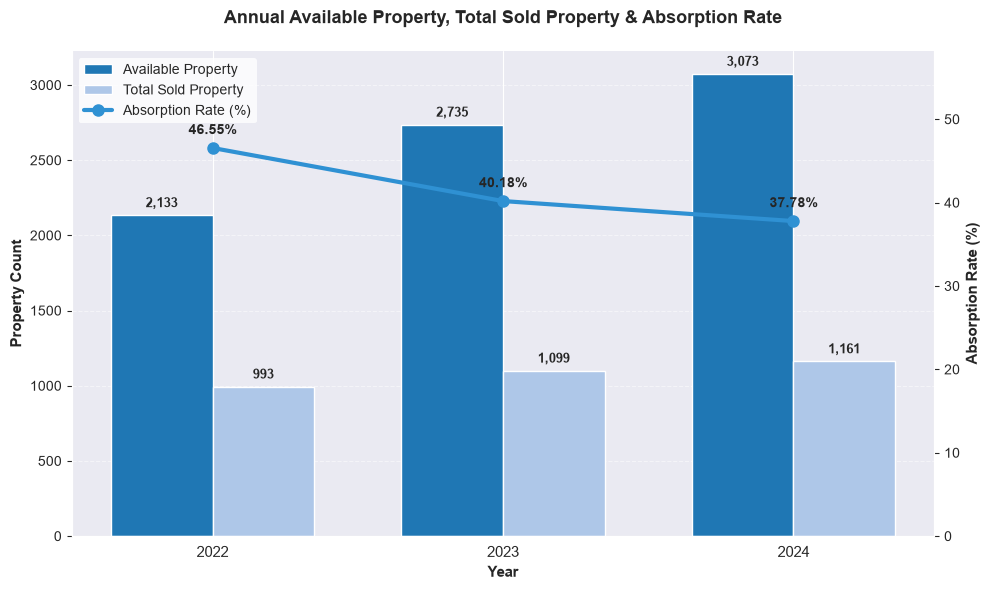

In [85]:

sns.set_style("darkgrid")
fig, ax1 = plt.subplots(figsize=(10, 6))

x = np.arange(len(annual_absoption_property["year"]))
width = 0.35

rects1 = ax1.bar(
    x - width / 2,
    annual_absoption_property["available_property"],
    width,
    label="Available Property",
    color="#1f77b4"
)
rects2 = ax1.bar(
    x + width / 2,
    annual_absoption_property["total_sold_property"],
    width,
    label="Total Sold Property",
    color="#aec7e8"
)

ax1.set_ylabel("Property Count", fontsize=11, fontweight="bold")
ax1.set_xlabel("Year", fontsize=11, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(annual_absoption_property["year"].astype(str), fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(
        f"{int(height):,}",
        xy=(rect.get_x() + rect.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax2 = ax1.twinx()

line_color = "#2f91d3"

line = ax2.plot(
    x,
    annual_absoption_property["absorption_rate"],
    color=line_color,
    marker="o",
    linewidth=3,
    markersize=8,
    label="Absorption Rate (%)",
)

ax2.set_ylabel("Absorption Rate (%)", fontsize=11, fontweight="bold")
ax2.tick_params(axis="y")
ax2.grid(False)

max_rate = annual_absoption_property["absorption_rate"].max()
ax2.set_ylim(0, max_rate * 1.25)

for i, txt in enumerate(annual_absoption_property["absorption_rate"]):
    ax2.annotate(
        f"{txt:.2f}%",
        (x[i], txt),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontweight="bold",
        fontsize=10,
    )

plt.title(
    "Annual Available Property, Total Sold Property & Absorption Rate",
    fontsize=13,
    fontweight="bold",
    pad=20,
    loc="center",
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
)

sns.despine(top=True, right=False)
plt.tight_layout()
plt.show()


>> 2) Property Type Listing Analysis

In [86]:
listing_by_property_type = (\
    df_listing
    .groupby('property_type')
    .agg(total_listing = ('listing_id','nunique')
         ,median_DOM = ('days_on_market','median')
         )
)

completed_trans = (\
    df_completed
    .groupby('property_type')
    .agg(total_completed_listing = ('listing_id','nunique')
         ,avg_rev = ('deal_price','mean'))
)

listing_property_type = listing_by_property_type.merge(completed_trans,on= 'property_type').reset_index()

listing_property_type['conversion_rate'] = round(\
    listing_property_type['total_completed_listing']/
    listing_property_type['total_listing']
    *100,2)

listing_property_type = (
    listing_property_type
    .sort_values('conversion_rate', ascending=False)
    .reset_index(drop=True)
)

listing_property_type

,property_type,total_listing,median_DOM,total_completed_listing,avg_rev,conversion_rate
0,Apartment,4683,72.0,2127,1.021544e+07,45.42
1,House,2216,83.0,958,1.857670e+07,43.23
2,Land,906,92.0,372,1.292615e+07,41.06
3,Commercial,695,106.0,280,2.574449e+07,40.29


>> 3) City Listing Analysis

>> a) Listing Conversion Rate by City

In [87]:
listing_by_city = (\
    df_listing
    .groupby('city')
    .agg(total_listing = ('listing_id','nunique'),
         median_DOM = ('days_on_market','median'))
)

completed_trans_city = (\
    df_completed
    .groupby('city')
    .agg(total_completed_listing = ('listing_id','nunique'))
)

listing_city = listing_by_city.merge(completed_trans_city, on= 'city').reset_index()

listing_city['conversion_rate'] = round(\
    listing_city['total_completed_listing']/
    listing_city['total_listing']
    *100,2)

listing_city = (
    listing_city
    .sort_values('conversion_rate', ascending=False)
    .reset_index(drop=True)
)

listing_city

,city,total_listing,median_DOM,total_completed_listing,conversion_rate
0,Barishal,612,70.0,287,46.90
1,Rajshahi,724,76.0,332,45.86
2,Sylhet,649,80.0,295,45.45
3,Dhaka,2527,76.0,1124,44.48
4,Chattogram,1575,82.0,678,43.05
5,Mymensingh,757,84.0,321,42.40
6,Khulna,959,90.0,406,42.34
7,Rangpur,697,89.0,294,42.18


>>b) Listing Absorption Rate by City

In [88]:
avail_list_by_city = []
years = (df_listing['listing_date'].dt.year).unique()

for year in years:
    start_date = pd.Timestamp(f'{year}-01-01')
    end_date = pd.Timestamp(f'{year}-12-31')

    carry_over_list = (\
        df_listing[
            (df_listing['listing_date']< start_date)&
            ((df_listing['close_date']>= start_date)|
             (df_listing['close_date'].isna())
             )
        ]
    )

    new_listing = (\
        df_listing[
            (df_listing['listing_date']>=start_date)&
            (df_listing['listing_date']<=end_date)
        ]

    )

    available_listing = (\
        pd.concat([carry_over_list,new_listing])
        .groupby('city')
        .agg(total_available_listing = ('listing_id','nunique'))
        .reset_index()
    )

    available_listing['year'] = year

    avail_list_by_city.append(available_listing)

annual_available_listing_city = pd.concat(avail_list_by_city,ignore_index=True)

annual_transaction_by_city = (\
    df_completed
    .groupby(['city',df_completed['deal_date'].dt.year])
    .agg(total_transaction = ('transaction_id','nunique'))
    .reset_index()
    .rename(columns = {'deal_date' : 'year'})
)

annual_absorption_rate_by_city = (\
    annual_available_listing_city
    .merge(annual_transaction_by_city,on =['city','year'])
)

annual_absorption_rate_by_city = annual_absorption_rate_by_city[['city','year','total_available_listing','total_transaction']]

annual_absorption_rate_by_city['absorption_rate'] = (\
    round(annual_absorption_rate_by_city['total_transaction']/
    annual_absorption_rate_by_city['total_available_listing']*100,2)

)

data =(\
    annual_absorption_rate_by_city
    .pivot(index = 'city',
            columns = 'year',
              values = ['total_transaction','total_available_listing','absorption_rate'])
)

annual_absorption_rate_by_city = annual_absorption_rate_by_city.sort_values('year')

data

total_transaction               total_available_listing          \
year                    2022   2023   2024                    2022    2023   
city                                                                         
Barishal                84.0  103.0  100.0                   201.0   303.0   
Chattogram             203.0  231.0  244.0                   550.0   813.0   
Dhaka                  338.0  380.0  406.0                   860.0  1277.0   
Khulna                 115.0  139.0  152.0                   304.0   486.0   
Mymensingh              88.0  114.0  119.0                   243.0   381.0   
Rajshahi               104.0  104.0  124.0                   260.0   346.0   
Rangpur                 95.0  110.0   89.0                   239.0   361.0   
Sylhet                  94.0   98.0  103.0                   222.0   318.0   

                   absorption_rate                
year          2024            2022   2023   2024  
city                                              
Barishal     353.0           41.79  33.99  28.33  
Chattogram   982.0           36.91  28.41  24.85  
Dhaka       1588.0           39.30  29.76  25.57  
Khulna       630.0           37.83  28.60  24.13  
Mymensingh   492.0           36.21  29.92  24.19  
Rajshahi     447.0           40.00  30.06  27.74  
Rangpur      432.0           39.75  30.47  20.60  
Sylhet       394.0           42.34  30.82  26.14

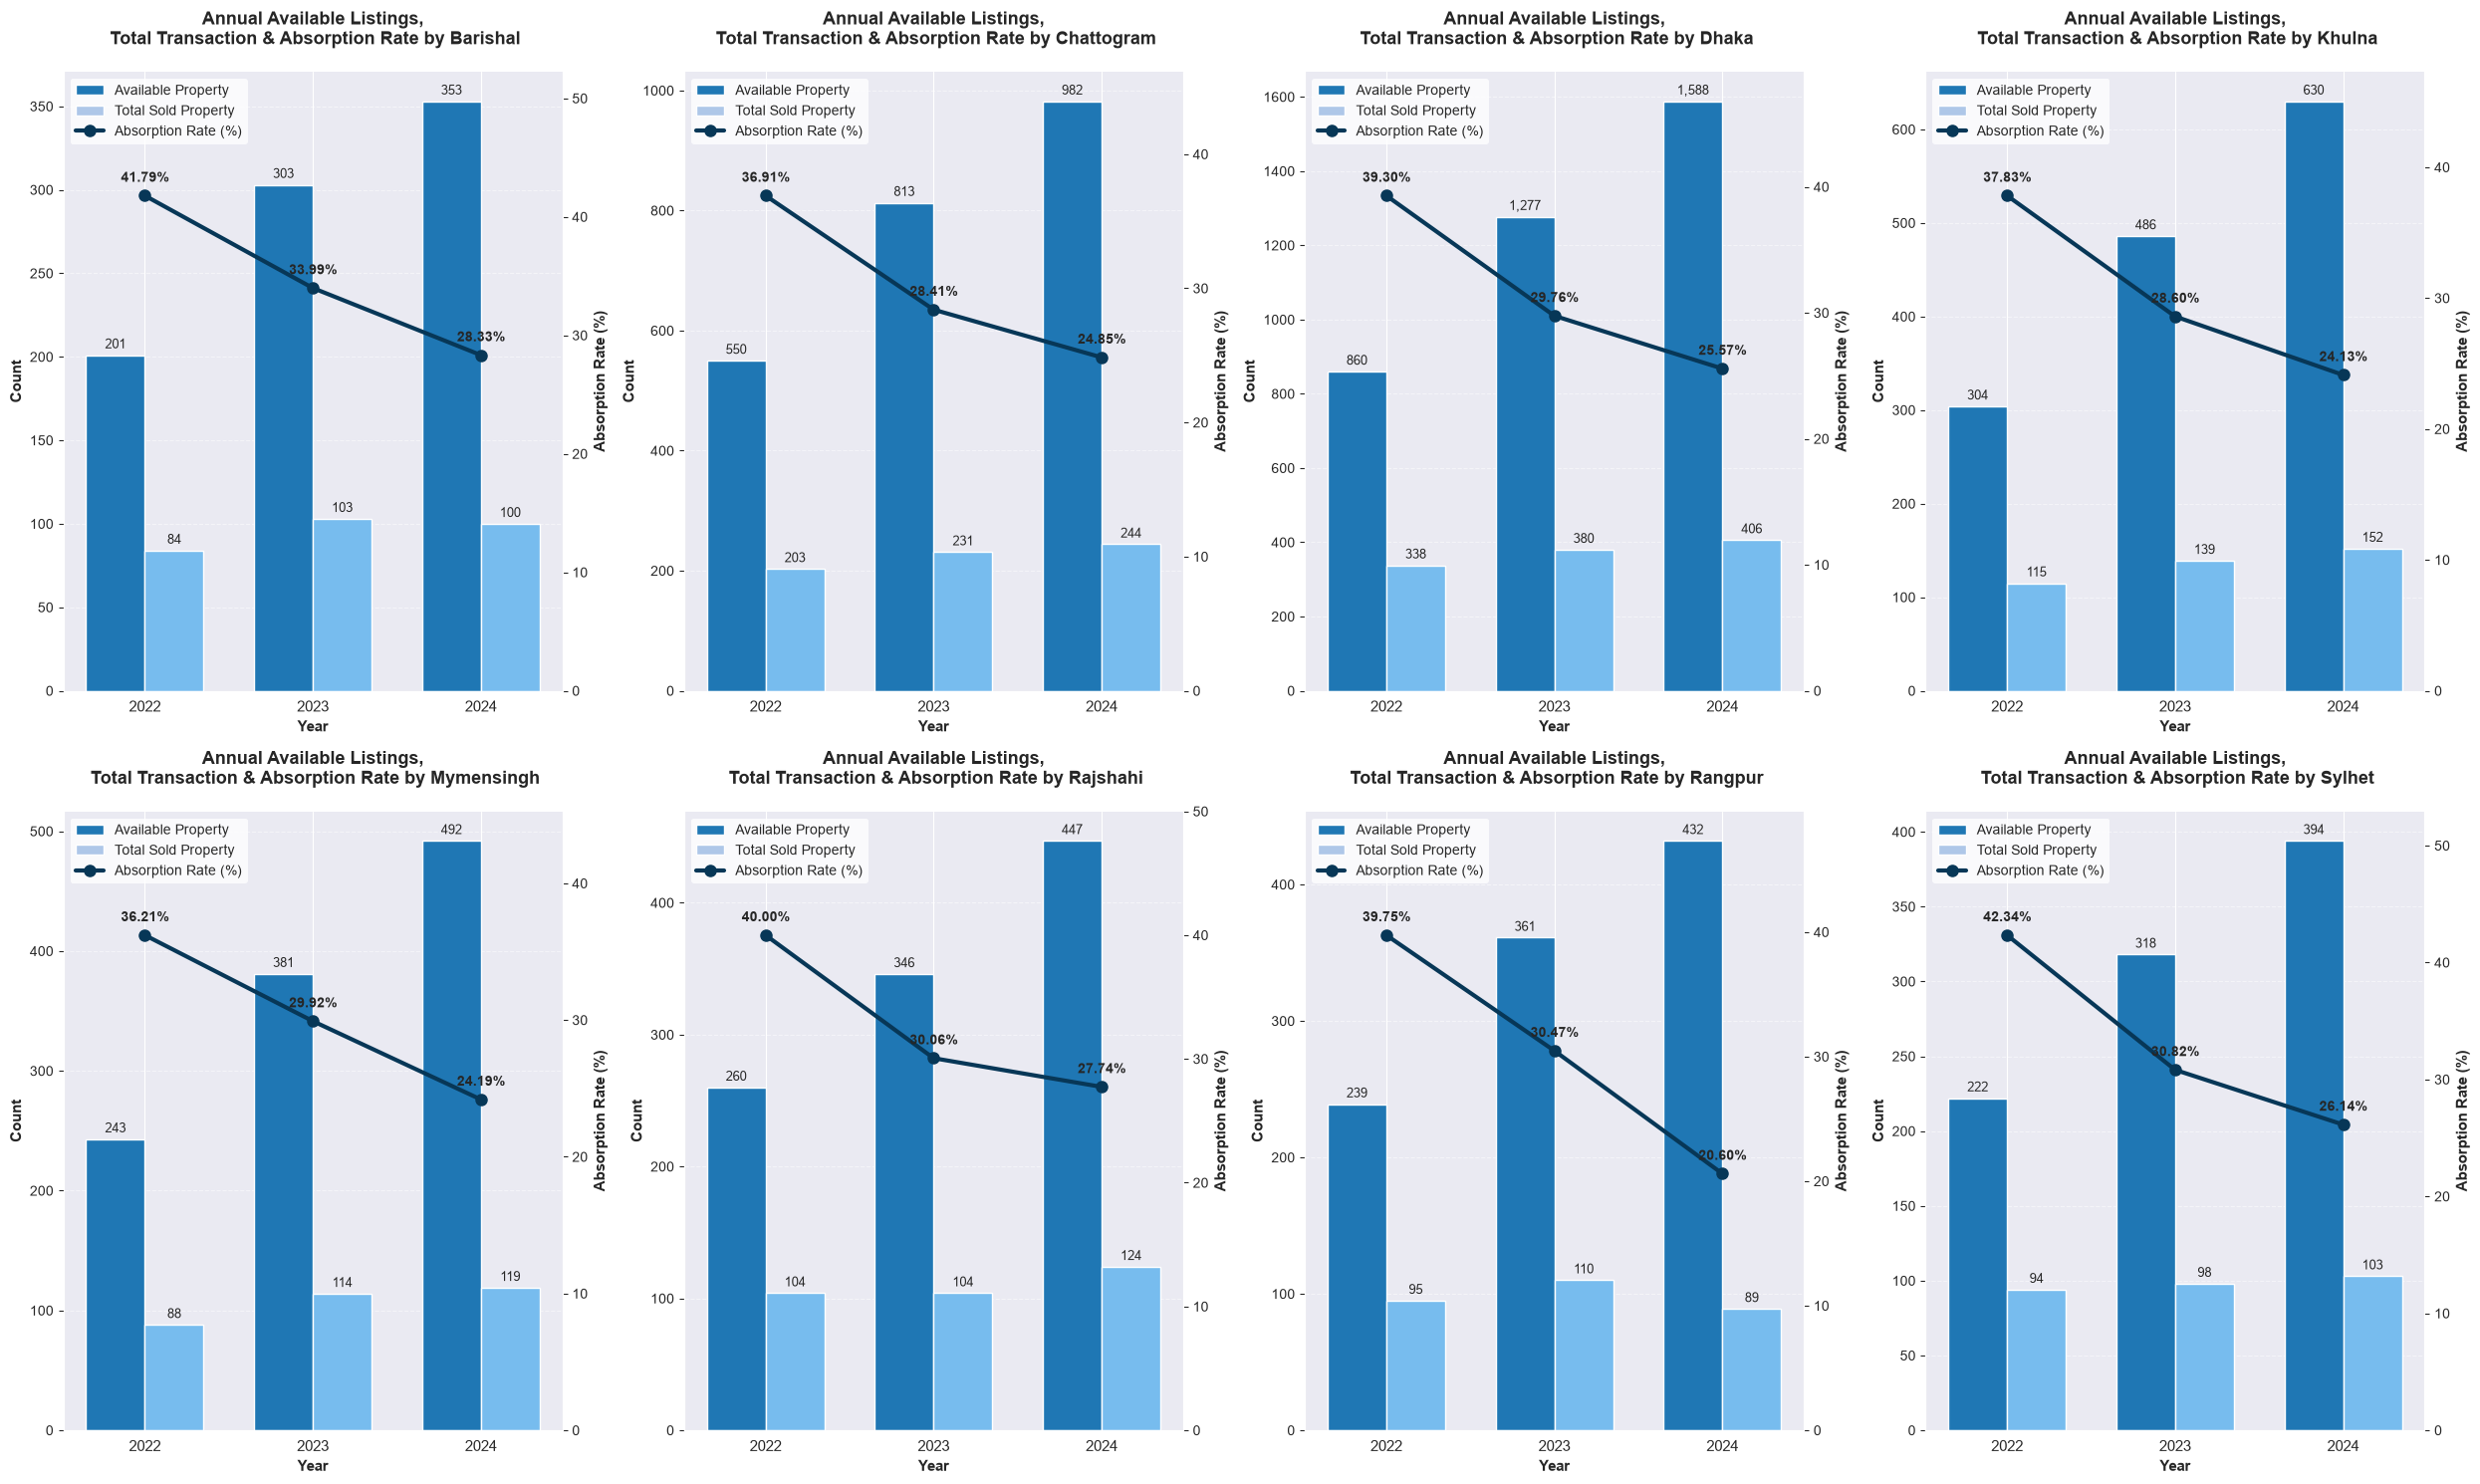

In [89]:
cities = annual_absorption_rate_by_city['city'].unique()

fig, axes = plt.subplots(
    nrows=2,
    ncols=4,
    figsize=(25, 15),
    sharex=False
)

axes = axes.flatten()

for ax, city in zip (axes,cities) :

	x = np.arange(len(annual_absorption_rate_by_city['year'].unique()))
	width = 0.35

	data = annual_absorption_rate_by_city[
		annual_absorption_rate_by_city['city']==city
	]

	rects1 = ax.bar(
			x - width / 2,
			data['total_available_listing'],
			width,
			label="Available Listing",
			color="#1f77b4"
			)
	rects2 = ax.bar(
			x + width / 2,
			data['total_transaction'],
			width,
			label="Transaction",
			color="#77bcee"
			)
	ax.set_ylabel('Count',fontsize=11, fontweight="bold")
	ax.set_xlabel('Year', fontsize=11, fontweight="bold")
	ax.set_xticks(x)
	ax.set_xticklabels(data['year'].astype(str),fontsize=11)
	ax.grid(axis="y", linestyle="--", alpha=0.5)
	ax.bar_label(rects1, fmt='{:,.0f}', padding=3, fontsize=9)
	ax.bar_label(rects2, fmt='{:,.0f}', padding=3, fontsize=9)
	
	ax2 = ax.twinx()
	line_color = "#073757"

	line = ax2.plot(
    			x,
    			data["absorption_rate"],
    			color=line_color,
    			marker="o",
    			linewidth=3,
    			markersize=8,
    			label="Absorption Rate (%)",
		)
	ax2.set_ylabel("Absorption Rate (%)", fontsize=11, fontweight="bold")
	ax2.tick_params(axis="y")
	ax2.grid(False)
	
	max_rate = data["absorption_rate"].max()
	ax2.set_ylim(0, max_rate * 1.25)
	
	for i, txt in enumerate(data["absorption_rate"]):
		ax2.annotate(
        		f"{txt:.2f}%",
        		(x[i], txt),
        		textcoords="offset points",
        		xytext=(0, 10),
        		ha="center",
        		fontweight="bold",
        		fontsize=10,
    		)
	plt.title(
		(f"Annual Available Listings,\n Total Transaction & Absorption Rate by {city}"),
		fontsize=13,
		fontweight="bold",
		pad=20,
		loc="center"
		)

	lines1, labels1 = ax1.get_legend_handles_labels()
	lines2, labels2 = ax2.get_legend_handles_labels()
	ax.legend(
		lines1 + lines2,
		labels1 + labels2,
		loc="upper left",
		frameon=True,
		facecolor="white",
    	edgecolor="none",
	)
sns.despine(top=True, right=False)
plt.tight_layout()
plt.show()

>> 4) Channel Listing Analysis

In [90]:
completed_by_channel = (\
    df_completed
    .groupby('listing_channel')
    .agg(total_completed_trans = ('transaction_id','count'),
        total_revenue = ('deal_price','sum'),
        median_DOM = ('days_on_market','median'))
)

listing_by_channel = (\
    df_listing
    .groupby('listing_channel')
    .agg(total_listing = ('listing_id','count'))
)

df_channel = (\
    listing_by_channel.merge(completed_by_channel, on = 'listing_channel')
    .sort_values(by= 'total_completed_trans', ascending = False)
    .reset_index()
)

df_channel['conversion_rate'] = (\
    round(
    df_channel['total_completed_trans']/
    df_channel['total_listing']*100,2)
)

df_channel

,listing_channel,total_listing,total_completed_trans,total_revenue,median_DOM,conversion_rate
0,Open,3826,1687,2.331081e+10,44.0,44.09
1,Exclusive,3605,1572,2.184554e+10,45.0,43.61
2,Partner,1069,478,6.385356e+09,44.0,44.71


##
REAL ESTATE EVALUATION & PRICING BENCHMARK

>> PRICING ANALYSIS

>>1) Price Property per Square Meter

In [91]:
df_completed['listed_price_per_sqrm'] = df_completed['listed_price']/df_listing['size_sqm']
df_completed['price_per_sqrm'] = df_completed['deal_price']/df_completed['size_sqm']
print(f"Average Listing Price per Square Meter : {(df_completed['listed_price_per_sqrm'].mean())/1e3:.2f}K")
print(f"Median Listing Price per Square Meter : {(df_completed['listed_price_per_sqrm'].median())/1e3:.2f}K")
print(f"Average Price per Square Meter : {(df_completed['price_per_sqrm'].mean())/1e3:.2f}K")
print(f"Median Price per Square Meter : {(df_completed['price_per_sqrm'].median())/1e3:.2f}K")
print(f'\n')

Average Listing Price per Square Meter : 116.61K
Median Listing Price per Square Meter : 104.77K
Average Price per Square Meter : 116.15K
Median Price per Square Meter : 103.62K




>> a) Price per Square Meter by Property Type

In [92]:
property_price_per_sqrm = (\
     df_completed
    .groupby('property_type')
    .agg(average_listing_per_sqrm = ('listed_price_per_sqrm','mean'),
         median_listing_per_sqrm = ('listed_price_per_sqrm','median'),
         average_price_per_sqrm = ('price_per_sqrm','mean'),
         median_price_per_sqrm = ('price_per_sqrm','median'),
         ).round(2)
    )

property_price_per_sqrm

,average_listing_per_sqrm,median_listing_per_sqrm,average_price_per_sqrm,median_price_per_sqrm
property_type,,,,
Apartment,117525.69,105972.96,117132.52,104476.85
Commercial,162349.03,145761.84,162013.94,143355.10
House,120689.43,110121.70,119998.94,109366.94
Land,66451.93,57726.43,66060.84,56628.95


>> b) Price per Square Meter by City

In [98]:
city_price_per_sqrm = (\
     df_completed
    .groupby('city')
    .agg(avg_listing_per_sqrm = ('listed_price_per_sqrm','mean'),
         median_listing_per_sqrm = ('listed_price_per_sqrm','median'),
         avg_price_per_sqrm = ('price_per_sqrm','mean'),
         median_price_per_sqrm = ('price_per_sqrm','median'),
         ).round(2)
    )


city_price_per_sqrm

,avg_listing_per_sqrm,median_listing_per_sqrm,avg_price_per_sqrm,median_price_per_sqrm
city,,,,
Barishal,81072.57,74448.23,78652.14,72026.77
Chattogram,127902.33,120552.33,127384.81,118712.83
Dhaka,157146.06,148273.73,159486.27,150094.33
Khulna,91998.08,84216.85,90106.02,82481.14
Mymensingh,88752.02,84841.83,86462.43,82170.02
Rajshahi,89169.44,83979.45,86983.01,81202.96
Rangpur,82048.34,78918.80,79416.20,76024.94
Sylhet,100307.14,96005.84,99225.59,95413.12


> 2) Property Age Impact

In [94]:
df_listing['property_age'] = 2024 - df_listing['year_built']

depreciation_rate = (\
    df_listing
    .select_dtypes(include='number')
    .corr(method='spearman')
)

depreciation_rate['property_age']

deal_price         0.030147
listed_price       0.022584
size_sqm          -0.008114
year_built        -1.000000
location_score     0.003442
list_price         0.022590
amenities_count   -0.018947
days_on_market    -0.007284
count_listing      0.019454
property_age       1.000000
Name: property_age, dtype: float64

>> 3) Facility & Feature Premium Index

In [95]:
df_property_sold = (\
    df_completed[['property_id','property_type','deal_price'
                  ,'city','size_sqm','has_parking', 'near_transit'
                  , 'near_school', 'amenities_count','price_per_sqrm']]
)


df_property_sold['amenities_status'] = (\
    np.where(
        df_property_sold['amenities_count']>=5,
        'High Amenities',
        'Low Amenities')
)

price_prop_has_parking = (\
    df_property_sold
    .groupby('has_parking')
    .agg(avg_price = ('price_per_sqrm','mean'),
         total_property = ('property_id','count'))
)

price_prop_amenities_status = (\
    df_property_sold
    .groupby('amenities_status')
    .agg(avg_price = ('price_per_sqrm','mean'),
         total_property = ('property_id','count'))
)

price_prop_near_transit = (\
    df_property_sold
    .groupby('near_transit')
    .agg(avg_price = ('price_per_sqrm','mean'),
        total_property = ('property_id','count'))
)

price_prop_near_school = (\
    df_property_sold
    .groupby('near_school')
    .agg(avg_price = ('price_per_sqrm','mean'),
        total_property = ('property_id','count'))
)

high_amenities = price_prop_amenities_status.loc['High Amenities','avg_price']
low_amenities = price_prop_amenities_status.loc['Low Amenities','avg_price']
amenities_premium = ((high_amenities - low_amenities) / low_amenities) * 100

no_parking = price_prop_has_parking.loc['False','avg_price']
has_parking = price_prop_has_parking.loc['True','avg_price']
parking_premium = ((has_parking - no_parking) / no_parking) * 100

no_near_school = price_prop_near_school.loc['False','avg_price']
near_school = price_prop_near_school.loc['True','avg_price']
near_school_premium = ((near_school - no_near_school) / no_near_school) * 100

no_near_transit = price_prop_near_transit.loc['False','avg_price']
near_transit = price_prop_near_transit.loc['True','avg_price']
near_transit_premium = ((near_transit - no_near_transit) / no_near_transit) * 100


print(f"Amenities Premium Index: {amenities_premium:.2f}%")
print(f"Parking Premium Index: {parking_premium:.2f}%")
print(f"Near School Premium Index: {near_school_premium:.2f}%")
print(f"Near Transit Premium Index: {near_transit_premium:.2f}%")

Amenities Premium Index: 15.94%
Parking Premium Index: -0.29%
Near School Premium Index: -3.06%
Near Transit Premium Index: 9.24%


>> MARKET IQUIDITY SCORE

In [96]:
from sklearn.preprocessing import MinMaxScaler
conversion_rate_by_city = listing_city[['city','conversion_rate']]

avg_absorption_by_city = (\
    annual_absorption_rate_by_city
    .groupby('city')['absorption_rate']
    .mean()
    .reset_index()
)

AVG_DOM_by_City = (\
    df_listing
    .groupby('city')['days_on_market']
    .median()
    .reset_index()
)

scaler = MinMaxScaler()

conversion_rate_by_city['conversion_rate_score'] = (
    scaler.fit_transform(
        conversion_rate_by_city[
            ['conversion_rate']
            ]
        )
)

avg_absorption_by_city['absorption_rate_score'] = (
    scaler.fit_transform(
        avg_absorption_by_city[
            ['absorption_rate']
            ]
        )
)


AVG_DOM_by_City['days_on_market_score'] = 1- (
    scaler.fit_transform(
        AVG_DOM_by_City[
            ['days_on_market']
            ]
        )
)


market_liquidity_score = (
    conversion_rate_by_city
    .merge(avg_absorption_by_city, on='city')
    .merge(AVG_DOM_by_City, on='city')
)


market_liquidity_score= (\
    market_liquidity_score[['city','conversion_rate_score'
                            ,'absorption_rate_score'
                            ,'days_on_market_score']]
)

market_liquidity_score['liquidity_score'] = (\
    (0.4*market_liquidity_score['absorption_rate_score'])+
    (0.3*market_liquidity_score['conversion_rate_score'])+
    (0.3*market_liquidity_score['days_on_market_score'])
)

market_liquidity_score


,city,conversion_rate_score,absorption_rate_score,days_on_market_score,liquidity_score
0,Barishal,1.000000,1.000000,1.00,1.000000
1,Rajshahi,0.779661,0.547346,0.70,0.662837
2,Sylhet,0.692797,0.654950,0.50,0.619819
3,Dhaka,0.487288,0.319943,0.70,0.484163
4,Chattogram,0.184322,0.000000,0.40,0.175297
5,Mymensingh,0.046610,0.010760,0.30,0.108287
6,Khulna,0.033898,0.027977,0.00,0.021360
7,Rangpur,0.000000,0.046628,0.05,0.033651


>> HIGH-DEMAND LOCATION INDEX

In [97]:
from sklearn.preprocessing import MinMaxScaler

data_city= (
    df_completed
    .groupby('city')
    .agg(total_transaction = ('transaction_id','count'),
         median_dom =('days_on_market','median'),
         total_revenue = ('deal_price','sum'))
    .reset_index()
)


location_index_score = data_city

scaler = MinMaxScaler() 

location_index_score['transaction_score'] = (
    scaler.fit_transform(
        location_index_score[
            ['total_transaction']
            ]
        )
)

location_index_score['DOM_score'] = 1- (
    scaler.fit_transform(
        location_index_score[
            ['median_dom']
            ]
        )
)

location_index_score['total_revenue_score'] = (
    scaler.fit_transform(
      location_index_score[
            ['total_revenue']
            ]
        )
)


location_index_score['location_index_score'] = (
    (location_index_score['transaction_score'] * 0.5) +
    (location_index_score['DOM_score'] * 0.2) +
    (location_index_score['total_revenue_score'] * 0.3)
)

location_index_score = (location_index_score.sort_values('location_index_score', ascending= False).reset_index(drop = True))

location_index_score

,city,total_transaction,median_dom,total_revenue,transaction_score,DOM_score,total_revenue_score,location_index_score
0,Dhaka,1124,44.0,2.107547e+10,1.000000,1.000000,1.000000,1.000000
1,Chattogram,678,44.0,1.002952e+10,0.467145,1.000000,0.400172,0.553624
2,Rangpur,294,44.0,2.876720e+09,0.008363,1.000000,0.011754,0.207708
3,Mymensingh,321,45.0,3.611587e+09,0.040621,0.666667,0.051660,0.169142
4,Khulna,406,46.0,4.370173e+09,0.142174,0.333333,0.092853,0.165610
5,Barishal,287,45.0,2.660260e+09,0.000000,0.666667,0.000000,0.133333
6,Rajshahi,332,47.0,3.392819e+09,0.053763,0.000000,0.039780,0.038816
7,Sylhet,295,47.0,3.525160e+09,0.009558,0.000000,0.046967,0.018869


>>The weights were assigned using expert judgment. Transaction activity received the highest weight (50%) as the primary indicator of market demand. Days on Market (30%) reflects market efficiency by measuring how quickly properties are sold. Convertion rate (20%) captures the market's ability to convert available inventory into completed transactions, but was assigned a lower weight because a convertion rate indicates faster inventory turnover rather than necessarily representing a larger market size or higher transaction value.